Decide models to compare

1. My Linear Regression
2. Scikit Linear Regression
3. Decision Tree (no limits)
4. Decision Tree (optimization from EmpiricalRiskEvaluator)

In [27]:
%load_ext autoreload
%autoreload 2
# imports 

import numpy as np
# preprocessing, training, model, and metrics
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder as OHencoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# model evaluation/cross-validation
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
# Linear Regression class
from NormalEquationSolver import projectionRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error

# for graphing
import matplotlib.pyplot as mlt
from matplotlib.widgets import Slider, Button

# for managing the csv datasets
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
# load in the csv file
data = pd.read_csv("Datasets/AmesHousing/AmesHousing.csv", index_col="Order")
data.describe()
# print(data.columns)

# set prediction variable and features
y = data.SalePrice
x = data
x.drop('SalePrice',axis=1,inplace=True)

# mark features with missing values dropped
excessive_missing = [
    col for col in x.columns # add any column missing atleast 80% of it's entries to the list
        if x[col].isnull().sum() >= (len(x[col])*0.8)
]

x.drop(excessive_missing,axis=1,inplace=True)

# mark features with very low variance to be dropped
lowVariance_cols = list()
for col in x.columns:
    length = x[col].count()
    relFreq = x[col].value_counts()
    for index, label in enumerate(relFreq.index.tolist()):
        if (relFreq[label]/length) >= 0.95:
            print("flag ",col," for low variance")
            lowVariance_cols.append(col)

x.drop(lowVariance_cols,axis=1,inplace=True)

categoricalCols = [
    col for col in x.columns
        if x[col].dtype == "object"
]

numericalCols = [
    col for col in x.columns
        if x[col].dtype in ['int64','float64']
]

# mark features with high skews to be transformed
skews_list = x.skew(numeric_only=True)
skewed_cols = (skews_list[skews_list > 1]).index.tolist() # collect a list of columns with 
                                                          # skewness values greater than 1

numericalCols = [
    col for col in numericalCols
        if col not in skewed_cols
]
print(x.columns)

flag  Street  for low variance
flag  Utilities  for low variance
flag  Land Slope  for low variance
flag  Condition 2  for low variance
flag  Roof Matl  for low variance
flag  Heating  for low variance
flag  Low Qual Fin SF  for low variance
flag  Kitchen AbvGr  for low variance
flag  Garage Cond  for low variance
flag  3Ssn Porch  for low variance
flag  Pool Area  for low variance
flag  Misc Val  for low variance
Index(['PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Lot Shape', 'Land Contour', 'Lot Config', 'Neighborhood',
       'Condition 1', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area',
       'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond',
       'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2',
       'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating QC',
       'Central Air'

In [29]:
# preprocessing
skewTransform = Pipeline(steps=[
        ('impute',SimpleImputer(strategy='mean')),
        ('scale',FunctionTransformer(np.log1p))
    ])
numTransform = SimpleImputer(strategy='mean')
catTransform = Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('ordinal',OHencoder(drop='first',sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('skew',skewTransform,skewed_cols),
        ('num',numTransform,numericalCols),
        ('cat',catTransform,categoricalCols)
    ]
)

In [30]:
X_train, X_valid, y_train, y_valid = train_test_split(
    x,y,
    train_size=0.8,
    test_size=0.2,
    random_state=0
)

In [ ]:
models = {
    "projRegression": projectionRegression(interceptEnabled=True),
    "LinRegression": LinearRegression(),
    "FreeTree": DecisionTreeRegressor(random_state=0),
    "OptimizedTree": DecisionTreeRegressor(max_leaf_nodes=62,random_state=1)
    }
Pipelines = dict() 
for index,key in models.items():
    entry = Pipeline(steps=[
        ('preprocess',preprocessor),
        ('model',models[index])
    ])
    Pipelines[index] = entry

'\nmy_pipe.fit(X_train,y_train)\nprint("Calculated Weights:", model.weights_)\n\nprediction = my_pipe.predict(X_valid)\n'

In [ ]:
MAE_scores = dict()
MSE_scores = dict()
for index,key in models.items():
    MAE_scores[index] = -1*cross_val_score(Pipelines[index], x, y, cv=5, scoring='neg_mean_absolute_error')
    MSE_scores[index] = -1*cross_val_score(Pipelines[index], x, y, cv=5, scoring='neg_mean_squared_error')
    print(index)
    print("Avg MAE:",MAE_scores[index].mean())
    print("Avg MSE:",MSE_scores[index].mean())

projRegression
Avg MAE: 22835.864580221714
Avg MSE: 1223020992.302395
LinRegression
Avg MAE: 40501.45094736202
Avg MSE: 3440058923.892968
FreeTree
Avg MAE: 24946.68737201365
Avg MSE: 1513328221.897611
OptimizedTree
Avg MAE: 23202.704913096353
Avg MSE: 1274518194.9286816


In [54]:
MAE_means = list()
MSE_means = list()

for index,entries in enumerate(MAE_scores):
    MAE_means.insert(index,MAE_scores[entries].mean())

for index,entries in enumerate(MSE_scores):
    MSE_means.insert(index,MSE_scores[entries].mean())

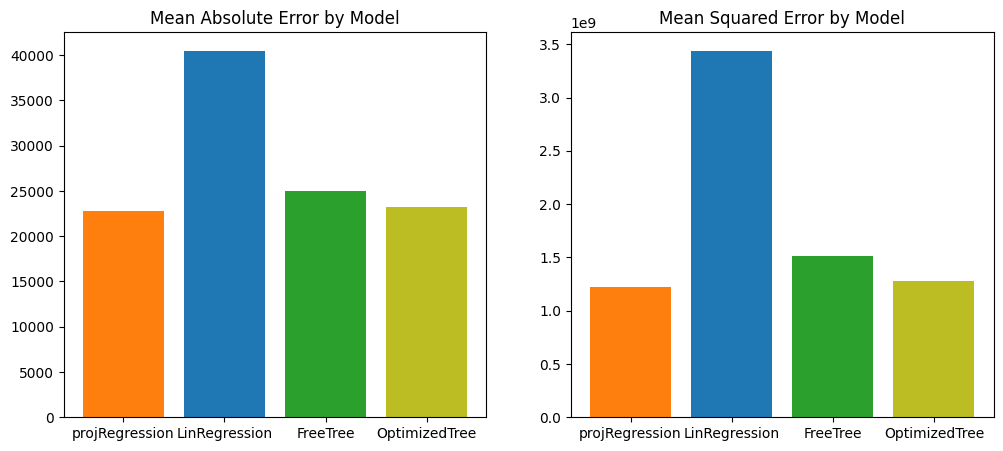

In [62]:
fig, ax = mlt.subplots(1,2)
fig.set_size_inches(12,5)
colors = ['tab:orange','tab:blue','tab:green','tab:olive']

ax[0].bar(MAE_scores.keys(),
          MAE_means,
          label=MAE_scores.keys(), 
          color=colors)
ax[0].set_title("Mean Absolute Error by Model")

ax[1].bar(MSE_scores.keys(),
          MSE_means,
          label=MSE_scores.keys(), 
          color=colors)
ax[1].set_title("Mean Squared Error by Model")

mlt.show()